In [46]:
# Input Image
# SET PYTHONPATH to the parent directory 
import os
import sys
import torch
import matplotlib.pyplot as plt
plt.rc('text', usetex=True)
from einops import rearrange
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from hippy2d.optimal_invariant_cnn import ComplexInvariantConv2DR, ComplexInvariantConv2D, FILTER_SIZE, MAX_ORDER

In [54]:
layer = ComplexInvariantConv2DR(filter_size=15,
                               max_order=4,
                               input_size=64,  
                               in_channels=1,
                               n_rings=5,
                               out_channels=1)
filters = layer.filters
filters = torch.view_as_complex(
    rearrange(layer.filters, '(co ch) i h w -> (ch i) h w co',co=2).contiguous()
)

filters.shape

torch.Size([10, 15, 15])

In [55]:

import numpy as np
import colorsys

def complex_to_rgb(Z):
    mag = np.abs(Z)
    phase = np.angle(Z)
    norm_mag = mag / mag.max()
    
    hsv = np.zeros(Z.shape + (3,))
    hsv[..., 0] = (phase + np.pi) / (2*np.pi)   # hue
    hsv[..., 1] = 1.0                           # saturation
    hsv[..., 2] = norm_mag                      # value
    
    rgb = np.zeros_like(hsv)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            rgb[i,j] = colorsys.hsv_to_rgb(*hsv[i,j])
    return rgb


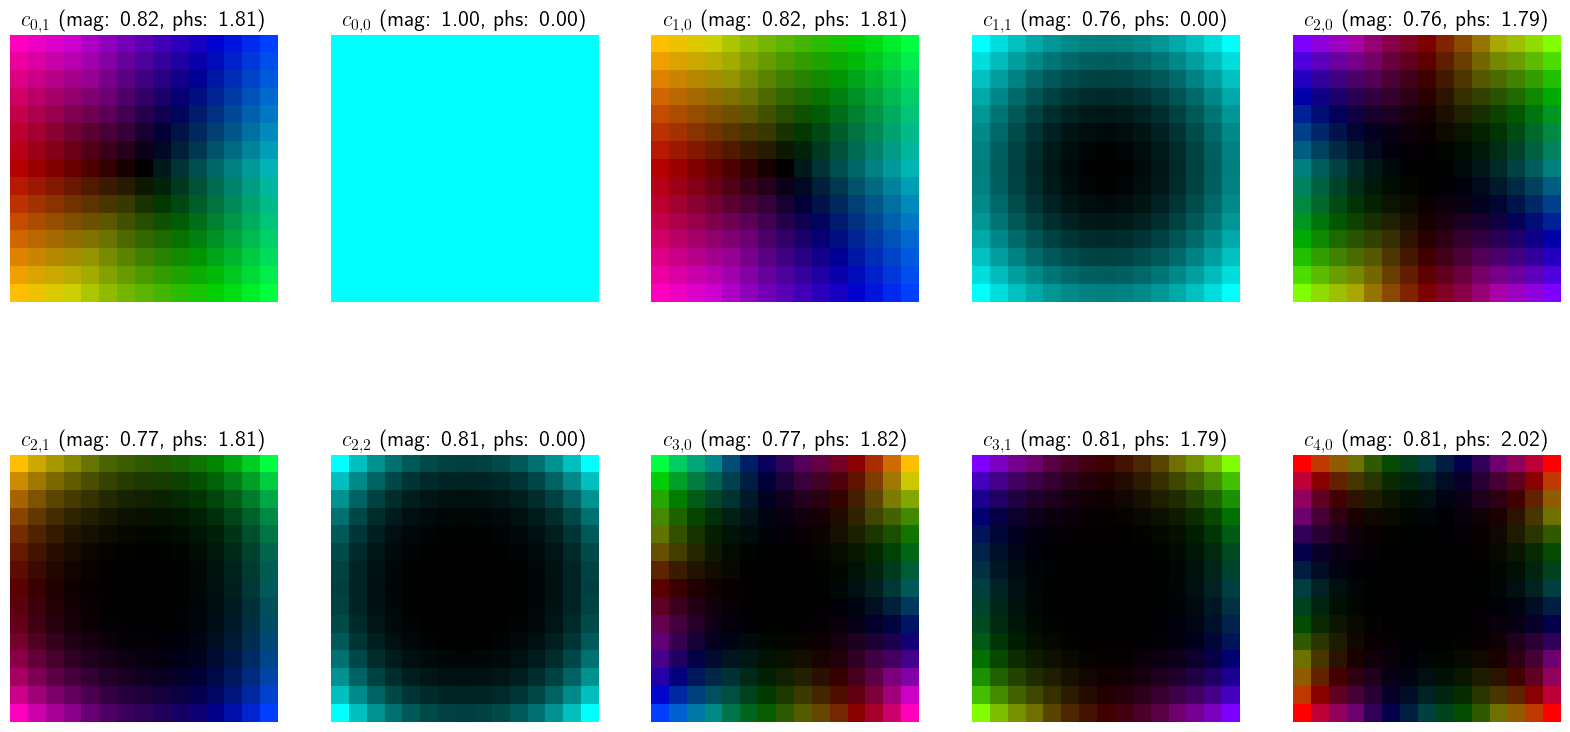

In [56]:

# Plot all the filters
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for i, ax in enumerate(axes.flat):
    if i < filters.shape[0]:
        ind = layer.ind[i]
        mn = filters[i].detach().cpu().abs().mean()
        angle_std = filters[i].detach().cpu().angle().std()
        rgb_image = complex_to_rgb(filters[i].detach().cpu().numpy())
        ax.imshow(rgb_image)
        ax.set_title(f'$c_{{{ind[0]},{ind[1]}}}$ (mag: {mn:.2f}, phs: {angle_std:.2f})', fontsize=16)
    ax.axis('off')

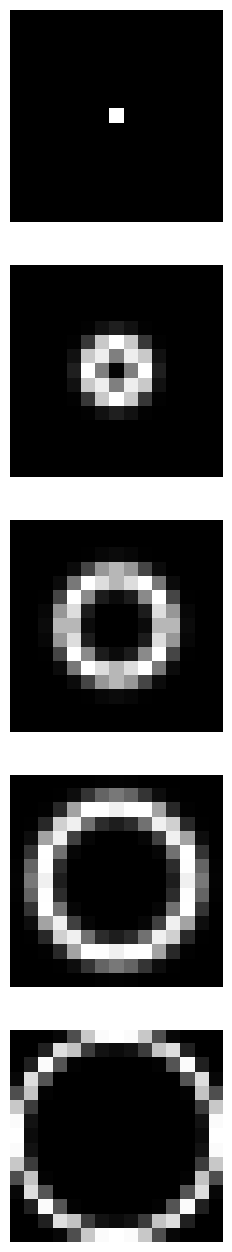

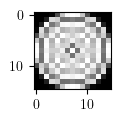

In [65]:
# Check the radial part 
radial_part =  layer._basis

# plot the rings
fig, axes = plt.subplots(5, 1, figsize=(4, 16))
for i, ax in enumerate(axes.flat):
    if i < radial_part.shape[0]:
        ax.imshow(radial_part[i].detach().cpu(), cmap='gray')
        # mean of the ring
        m = radial_part[i].detach().cpu().sum()
        #ax.set_title(f'Ring {i+1} - {m:.2f}', fontsize=16, )
    ax.axis('off')

# Plot sum
plt.figure(figsize=(5, 1))
radial_part =  torch.einsum("cmr,rhw->cmhw", layer.coeff, layer._basis)[0,0].detach()# [1 Moments InChannels H W]
m = radial_part.mean()
plt.imshow(radial_part, cmap='gray')
#plt.title(f'Sum of rings - {m:.2f}', fontsize=16)

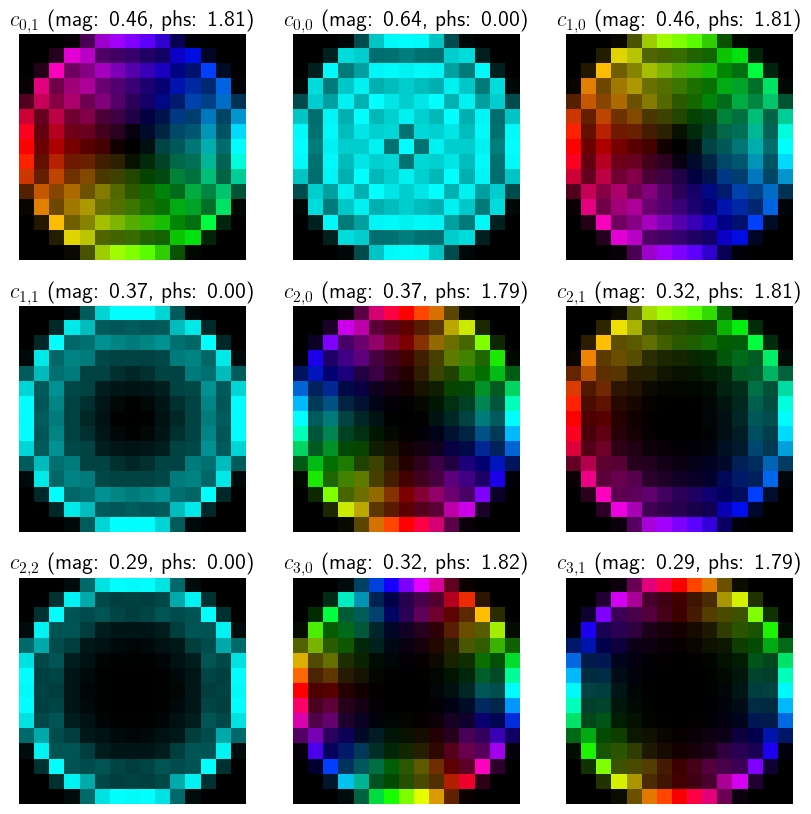

In [11]:
# Plot invariants after the radial part is applied
radial_part =  torch.einsum("cmr,rhw->cmhw", layer.coeff, layer._basis)# [1 Moments InChannels H W]

# Apply weights on the filters
filters = torch.view_as_complex(rearrange((layer.filters * radial_part[:, None])[0, :, :],
                    "co m h w -> m h w co").contiguous())

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < filters.shape[0]:
        ind = layer.ind[i]
        mn = filters[i].detach().cpu().abs().mean()
        angle_std = filters[i].detach().cpu().angle().std()
        rgb_image = complex_to_rgb(filters[i].detach().cpu().numpy())
        ax.imshow(rgb_image)
        ax.set_title(f'$c_{{{ind[0]},{ind[1]}}}$ (mag: {mn:.2f}, phs: {angle_std:.2f})', fontsize=16)
    ax.axis('off')

In [12]:
import torch
import math

# -----------------------------
# Utilities: grid & target
# -----------------------------
def radial_grid(H, W, device=None, dtype=torch.float32):
    yy, xx = torch.meshgrid(
        torch.arange(H, dtype=dtype, device=device) - (H-1)/2,
        torch.arange(W, dtype=dtype, device=device) - (W-1)/2,
        indexing='ij'
    )
    r = torch.sqrt(xx*xx + yy*yy)
    R = 0.5*torch.tensor([H-1., W-1.], device=device, dtype=dtype).min()
    return r, R

def tukey_disk(H, W, alpha=0.5, device=None, dtype=torch.float32):
    r, R = radial_grid(H, W, device=device, dtype=dtype)
    u = r / R
    T = torch.zeros_like(r)
    flat = u <= (1 - alpha)
    T[flat] = 1.0
    mask = (u > (1 - alpha)) & (u <= 1.0)
    # 0.5*(1 + cos(pi*( (u-(1-a))/a )))
    T[mask] = 0.5 * (1.0 + torch.cos(math.pi * ( (u[mask] - (1 - alpha)) / alpha )))
    T[u > 1.0] = 0.0
    return T

# -------------------------------------------
# Ring families (Gaussian / RaisedCosine / Kaiser)
# -------------------------------------------
def gaussian_ring(r, rho, sigma):
    # exp(- (r - rho)^2 / (2 sigma^2))
    return torch.exp(-0.5 * ((r - rho) / sigma)**2)

def raised_cosine_ring(r, rho, w):
    # 0.5*(1 + cos(pi*(r-rho)/w)) inside |r-rho| <= w, else 0
    x = (r - rho) / w
    M = torch.zeros_like(r)
    inside = torch.abs(x) <= 1.0
    M[inside] = 0.5 * (1.0 + torch.cos(math.pi * x[inside]))
    return M

def kaiser_bessel_ring(r, rho, w, beta=6.0):
    # I0(beta*sqrt(1 - ((r-rho)/w)^2)) / I0(beta) for |r-rho| <= w, else 0
    x = (r - rho) / w
    inside = torch.abs(x) <= 1.0
    M = torch.zeros_like(r)
    # torch.special.i0e(x) * exp(|x|) = I0(x)
    z = beta * torch.sqrt(torch.clamp(1.0 - x[inside]**2, min=0.0))
    I0_num = torch.special.i0e(z) * torch.exp(torch.abs(z))
    I0_den = torch.special.i0e(torch.tensor(beta, device=r.device, dtype=r.dtype)) * torch.exp(torch.tensor(beta, device=r.device, dtype=r.dtype))
    M[inside] = I0_num / I0_den
    return M

# -------------------------------------------
# Build ring bases
# -------------------------------------------
def build_rings(H, W, N, basis="gaussian", alpha=0.5, device=None, dtype=torch.float32,
                radii=None, widths=None, beta=6.0, pad=1.0):
    """
    Returns rings [N,H,W], along with (rhos, widths) used.
    Ensures max radius is at most R - pad (default pad=1 px).
    """
    r, R = radial_grid(H, W, device=device, dtype=dtype)

    # apply padding
    R_eff = R - pad
    if R_eff <= 0:
        raise ValueError("Filter too small for pad >= R")

    # default placements: evenly spaced radii (including the rim at R_eff)
    if radii is None:
        if N == 1:
            radii = torch.tensor([0.0], device=device, dtype=dtype)
        else:
            radii = torch.linspace(0.0, R_eff.item(), N, device=device, dtype=dtype)
    else:
        radii = torch.as_tensor(radii, device=device, dtype=dtype)
        assert radii.numel() == N
        # clamp to max radius
        radii = torch.clamp(radii, 0.0, R_eff)

    if widths is None:
        if basis == "gaussian":
            spacing = max(R_eff.item() / max(N-1, 1), 1e-6)
            widths = torch.full((N,), 0.45*spacing, device=device, dtype=dtype)
        else:
            spacing = max(R_eff.item() / max(N-1, 1), 1e-6)
            widths = torch.full((N,), 0.75*spacing, device=device, dtype=dtype)
    else:
        widths = torch.as_tensor(widths, device=device, dtype=dtype)
        assert widths.numel() == N

    rings = []
    for k in range(N):
        rho = radii[k]
        w   = widths[k]
        if basis == "gaussian":
            rings.append(gaussian_ring(r, rho, w))
        elif basis == "raised_cosine":
            rings.append(raised_cosine_ring(r, rho, w))
        elif basis == "kaiser":
            rings.append(kaiser_bessel_ring(r, rho, w, beta=beta))
        else:
            raise ValueError("basis must be 'gaussian', 'raised_cosine', or 'kaiser'")
    rings = torch.stack(rings, dim=0)  # [N,H,W]
    return rings, radii, widths, R_eff

# -------------------------------------------
# Fit weights: LS or NNLS
# -------------------------------------------
def fit_weights(rings, target, nonneg=True, iters=800, step=None):
    """
    rings:  [N,H,W]
    target: [H,W]
    Returns coef [N] (1-D), minimizing || sum_i w_i * ring_i - target ||_2^2
    If nonneg: projected gradient descent on the quadratic; else closed-form LS.
    """
    N, H, W = rings.shape
    B = rings.reshape(N, -1)         # [N, HW]
    t = target.reshape(-1)           # [HW]
    # Normal equations
    A = B @ B.T                      # [N,N]
    b = B @ t                        # [N]

    if not nonneg:
        # Unconstrained LS
        coef = torch.linalg.lstsq(A, b).solution
        return coef

    # Projected gradient on 0.5 w^T A w - b^T w
    # Lipschitz const ~ largest eig(A); estimate by power iteration
    with torch.no_grad():
        v = torch.randn(N, device=B.device, dtype=B.dtype)
        v = v / (v.norm() + 1e-12)
        for _ in range(12):
            v = A @ v
            v = v / (v.norm() + 1e-12)
        L = torch.dot(v, A @ v).clamp(min=1e-6).item()
    if step is None:
        step = 1.0 / L

    w = torch.zeros(N, device=B.device, dtype=B.dtype)
    for _ in range(iters):
        grad = A @ w - b
        w = w - step * grad
        w = torch.clamp(w, min=0.0)
    return w

# -------------------------------------------
# Public API
# -------------------------------------------
def design_tukey_rings(H, W, num_rings, basis="gaussian", alpha=0.5,
                       nonneg=True, device=None, dtype=torch.float32,
                       radii=None, widths=None, beta=6.0, normalize_sum1=True):
    """
    Build N blurry rings on an HxW grid and fit weights to approximate a circular Tukey target.
    Returns:
      rings: [N,H,W]
      coef:  [N,1,1]
      meta:  dict with radii, widths, R
    """
    rings, rhos, ws, R = build_rings(H, W, num_rings, basis=basis, alpha=alpha,
                                     device=device, dtype=dtype, radii=radii, widths=widths, beta=beta)
    target = tukey_disk(H, W, alpha=alpha, device=device, dtype=dtype)

    coef = fit_weights(rings, target, nonneg=nonneg)  # [N]

    # Build approximation & (optionally) normalize kernel to sum=1
    approx = (coef.view(-1,1,1) * rings).sum(dim=0)   # [H,W]
    if normalize_sum1:
        s = approx.sum()
        if s.abs() > 0:
            coef = coef / s

    return rings, coef.view(-1,1,1), {"radii": rhos, "widths": ws, "R": R, "alpha": alpha, "basis": basis}


In [28]:

# -------------------------------------------
# Example usage
# -------------------------------------------
H = W = 15
N = 3


{'radii': tensor([0., 3., 6.]),
 'widths': tensor([1.3500, 1.3500, 1.3500]),
 'R': tensor(6.),
 'alpha': 0.5,
 'basis': 'gaussian'}

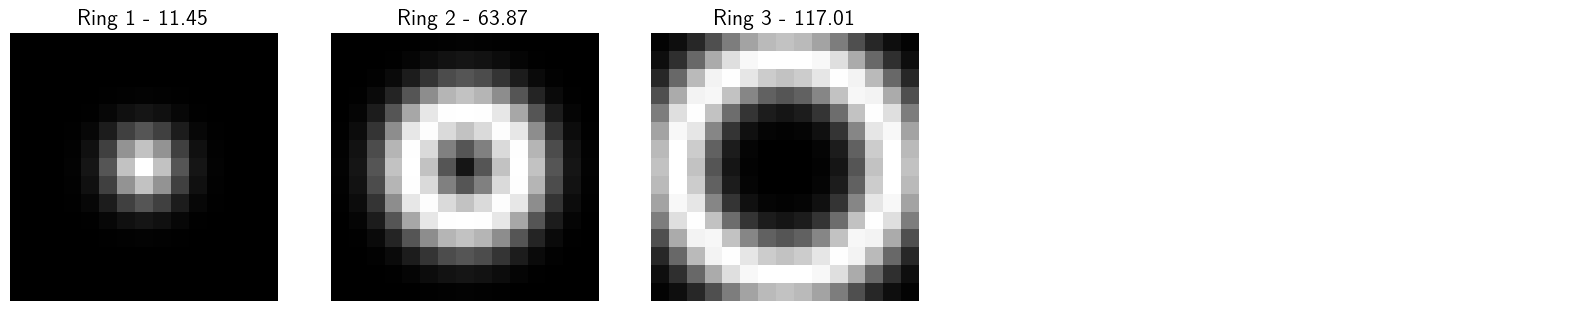

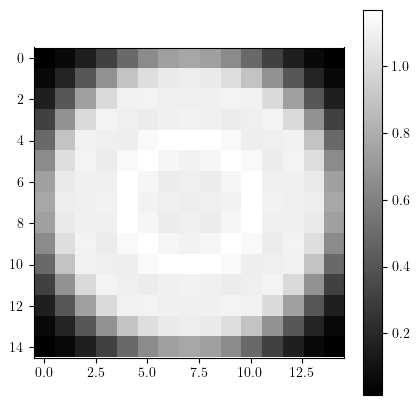

In [34]:

# 1) Gaussian rings (nonnegative weights)
rings_g, coef_g, meta_g = design_tukey_rings(H, W, N, basis="gaussian", alpha=0.5, nonneg=True)
kernel_g = (coef_g * rings_g).sum(dim=0)  # [H,W]

# Plot all the rings
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    if i < rings_g.shape[0]:
        ax.imshow(rings_g[i].detach().cpu(), cmap='gray')
        # mean of the ring
        m = rings_g[i].detach().cpu().sum()
        ax.set_title(f'Ring {i+1} - {m:.2f}', fontsize=16, )
    ax.axis('off')

plt.figure(figsize=(5, 5))
plt.imshow(rings_g.sum(dim=0), cmap='gray')
plt.colorbar()
meta_g

RaisedCosine: torch.Size([3, 15, 15]) torch.Size([3, 1, 1]) sum(kernel)= 1.0


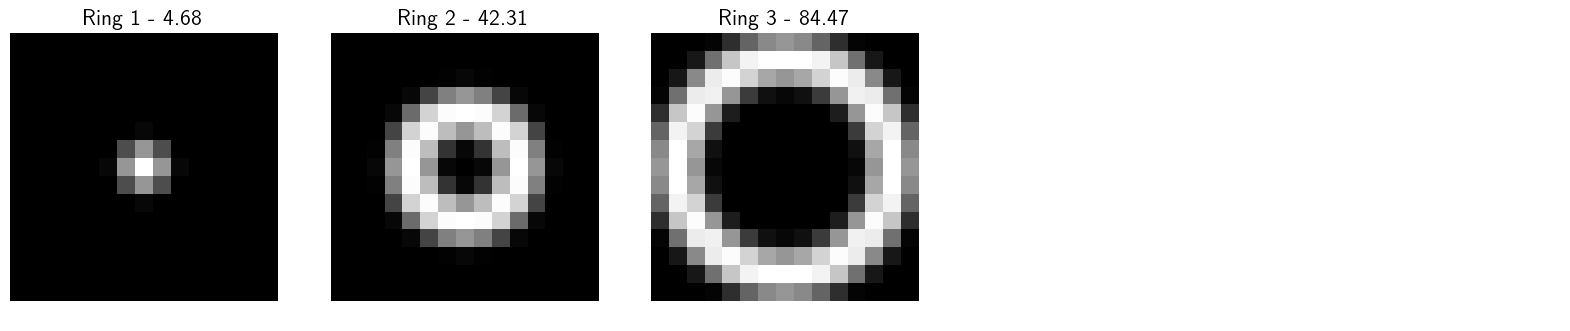

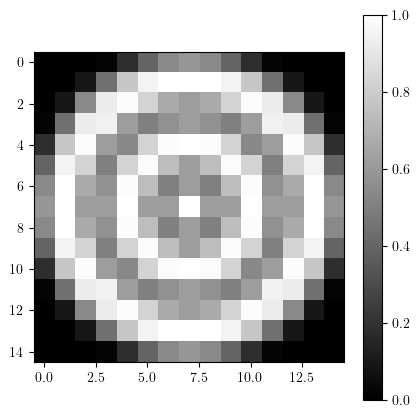

In [30]:

# 2) Raised-cosine rings
rings_rc, coef_rc, meta_rc = design_tukey_rings(H, W, N, basis="raised_cosine", alpha=0.5, nonneg=True)
kernel_rc = (coef_rc * rings_rc).sum(dim=0)
print("RaisedCosine:", rings_rc.shape, coef_rc.shape, "sum(kernel)=", float(kernel_rc.sum()))

# Plot the rings
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    if i < rings_rc.shape[0]:
        ax.imshow(rings_rc[i].detach().cpu(), cmap='gray')
        # mean of the ring
        m = rings_rc[i].detach().cpu().sum()
        ax.set_title(f'Ring {i+1} - {m:.2f}', fontsize=16, )
    ax.axis('off')
# Plot sum with coef 
plt.figure(figsize=(5, 5))
plt.imshow(rings_rc.sum(dim=0), cmap='gray')
plt.colorbar()

Kaiser: torch.Size([3, 15, 15]) torch.Size([3, 1, 1]) sum(kernel)= 1.0


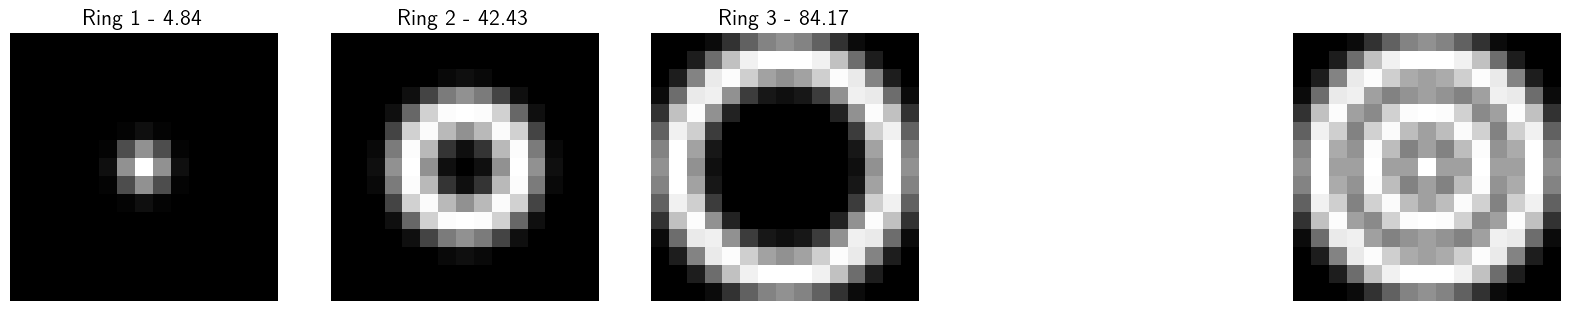

In [32]:

# 3) Kaiser–Bessel rings (beta controls blur; larger beta = sharper)
rings_k, coef_k, meta_k = design_tukey_rings(H, W, N, basis="kaiser", alpha=0.5, nonneg=True, beta=6.0)
kernel_k = (coef_k * rings_k).sum(dim=0)
print("Kaiser:", rings_k.shape, coef_k.shape, "sum(kernel)=", float(kernel_k.sum()))

# Plot all the rings
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    if i < rings_k.shape[0]:
        ax.imshow(rings_k[i].detach().cpu(), cmap='gray')
        # mean of the ring
        m = rings_k[i].detach().cpu().sum()
        ax.set_title(f'Ring {i+1} - {m:.2f}', fontsize=16, )
    ax.axis('off')
plt.imshow(rings_k.sum(dim=0), cmap='gray')

In [35]:
import math
import torch

# -----------------------
# Radial grid + Tukey
# -----------------------
def radial_grid(H, W, device=None, dtype=torch.float32):
    yy, xx = torch.meshgrid(
        torch.arange(H, dtype=dtype, device=device) - (H-1)/2,
        torch.arange(W, dtype=dtype, device=device) - (W-1)/2,
        indexing='ij'
    )
    r = torch.sqrt(xx*xx + yy*yy)
    R = 0.5*torch.tensor([H-1., W-1.], device=device, dtype=dtype).min()
    return r, R

def tukey_disk(H, W, alpha=0.5, device=None, dtype=torch.float32):
    r, R = radial_grid(H, W, device=device, dtype=dtype)
    u = r / R
    T = torch.zeros_like(r)
    flat = u <= (1 - alpha)
    T[flat] = 1.0
    mask = (u > (1 - alpha)) & (u <= 1.0)
    T[mask] = 0.5 * (1.0 + torch.cos(math.pi * ( (u[mask] - (1 - alpha)) / alpha )))
    return T

# -----------------------
# Bessel J0 zeros (fast Newton refine)
# initial guess: (k - 1/4)*pi (good for k>=1)
# -----------------------
def j0_zeros(num, device=None, dtype=torch.float32, iters=15):
    k = torch.arange(1, num+1, device=device, dtype=dtype)
    z = (k - 0.25) * math.pi  # initial
    for _ in range(iters):
        # Newton step: z <- z - J0(z)/J1(z)
        f  = torch.special.j0(z)
        fp = torch.special.j1(z)  # derivative of J0 is -J1, but Newton uses f/f'
        z  = z - f / (-fp)        # because f' = dJ0/dz = -J1
    return z  # ~ j_{0,n}

# -----------------------
# Build Fourier–Bessel modes (m=0)
# phi_n(r) = J0(j0n * r / R_eff), with Dirichlet at R_eff
# -----------------------
def fb_modes(H, W, N, pad=1.0, device=None, dtype=torch.float32):
    r, R = radial_grid(H, W, device=device, dtype=dtype)
    R_eff = R - pad  # keep at least 'pad' px inside the boundary
    if R_eff <= 0:
        raise ValueError("Filter too small for the given padding.")
    j0n = j0_zeros(N, device=device, dtype=dtype)
    s = (j0n.view(-1, 1, 1) / R_eff) * r  # [N,H,W] argument
    modes = torch.special.j0(s)            # [N,H,W]
    # Optional: orthonormalize across the grid? Usually not needed for LS.
    return modes, R_eff

# -----------------------
# Fit weights (LS or NNLS)
# -----------------------
def fit_weights(rings, target, nonneg=True, iters=800, step=None):
    N, H, W = rings.shape
    B = rings.reshape(N, -1)         # [N, HW]
    t = target.reshape(-1)           # [HW]
    A = B @ B.T                      # [N,N]
    b = B @ t                        # [N]
    if not nonneg:
        coef = torch.linalg.lstsq(A, b).solution
        return coef
    # NNLS by projected gradient on 0.5 w^T A w - b^T w
    with torch.no_grad():
        v = torch.randn(N, device=B.device, dtype=B.dtype)
        v = v / (v.norm() + 1e-12)
        for _ in range(12):
            v = A @ v
            v = v / (v.norm() + 1e-12)
        L = torch.dot(v, A @ v).clamp(min=1e-6).item()
    if step is None:
        step = 1.0 / L
    w = torch.zeros(N, device=B.device, dtype=B.dtype)
    for _ in range(iters):
        grad = A @ w - b
        w = torch.clamp(w - step * grad, min=0.0)
    return w

# -----------------------
# Public API (Fourier–Bessel)
# -----------------------
def design_tukey_fourier_bessel(H, W, num_modes, alpha=0.5, pad=1.0,
                                nonneg=True, normalize_sum1=True,
                                device=None, dtype=torch.float32):
    """
    Returns:
      modes: [N, H, W]  (Fourier–Bessel radial modes)
      coef:  [N, 1, 1]  (weights)
      meta:  dict
    """
    modes, R_eff = fb_modes(H, W, num_modes, pad=pad, device=device, dtype=dtype)
    target = tukey_disk(H, W, alpha=alpha, device=device, dtype=dtype)
    coef = fit_weights(modes, target, nonneg=nonneg)  # [N]

    kernel = (coef.view(-1,1,1) * modes).sum(dim=0)
    if normalize_sum1:
        s = kernel.sum()
        if s.abs() > 0:
            coef = coef / s
            kernel = kernel / s

    return modes, coef.view(-1,1,1), {"R_eff": R_eff, "alpha": alpha, "basis": "fourier-bessel"}

# -----------------------
# Example
# -----------------------
if __name__ == "__main__":
    H = W = 15
    N = 7  # try 5, 7, 9...
    modes, coef, meta = design_tukey_fourier_bessel(H, W, N, alpha=0.5, pad=1.0, nonneg=True)
    kernel = (coef * modes).sum(dim=0)
    print("modes:", modes.shape, "coef:", coef.shape, "sum(kernel)=", float(kernel.sum()))


AttributeError: module 'torch.special' has no attribute 'j0'

In [36]:
def radial_grid(H, W, device=None, dtype=torch.float32):
    yy, xx = torch.meshgrid(
        torch.arange(H, dtype=dtype, device=device) - (H-1)/2,
        torch.arange(W, dtype=dtype, device=device) - (W-1)/2,
        indexing='ij'
    )
    r = torch.sqrt(xx*xx + yy*yy)
    R = 0.5*torch.tensor([H-1., W-1.], device=device, dtype=dtype).min()
    return r, R

In [40]:
r, R = radial_grid(15, 15)

In [43]:
r / 7

tensor([[1.4142, 1.3171, 1.2289, 1.1518, 1.0880, 1.0400, 1.0102, 1.0000, 1.0102,
         1.0400, 1.0880, 1.1518, 1.2289, 1.3171, 1.4142],
        [1.3171, 1.2122, 1.1157, 1.0302, 0.9583, 0.9035, 0.8690, 0.8571, 0.8690,
         0.9035, 0.9583, 1.0302, 1.1157, 1.2122, 1.3171],
        [1.2289, 1.1157, 1.0102, 0.9147, 0.8330, 0.7693, 0.7284, 0.7143, 0.7284,
         0.7693, 0.8330, 0.9147, 1.0102, 1.1157, 1.2289],
        [1.1518, 1.0302, 0.9147, 0.8081, 0.7143, 0.6389, 0.5890, 0.5714, 0.5890,
         0.6389, 0.7143, 0.8081, 0.9147, 1.0302, 1.1518],
        [1.0880, 0.9583, 0.8330, 0.7143, 0.6061, 0.5151, 0.4518, 0.4286, 0.4518,
         0.5151, 0.6061, 0.7143, 0.8330, 0.9583, 1.0880],
        [1.0400, 0.9035, 0.7693, 0.6389, 0.5151, 0.4041, 0.3194, 0.2857, 0.3194,
         0.4041, 0.5151, 0.6389, 0.7693, 0.9035, 1.0400],
        [1.0102, 0.8690, 0.7284, 0.5890, 0.4518, 0.3194, 0.2020, 0.1429, 0.2020,
         0.3194, 0.4518, 0.5890, 0.7284, 0.8690, 1.0102],
        [1.0000, 0.8571, 0.

In [42]:
spacing = max(R_eff.item() / max(N-1, 1), 1e-6)
widths = torch.full((N,), 0.45*spacing, device=device, dtype=dtype)

tensor(7.)